In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# 🔥 1. 데이터 (작고 noisy하게)
np.random.seed(42)

X = np.linspace(0, 1, 50) # 0부터 1까지를 50개로 균등하게 나눔 #[0.0, 0.0204, 0.0408, ..., 1.0]
y = 3 * X + np.random.normal(0, 0.1, 50)  # noise 추가 = y = 직선 + 약간의 흔들림

X = X.reshape(-1, 1)

# 🔥 2. 모델 (과하게 크게 만들어서 overfitting 유도)
model = Sequential([
    Dense(128, activation='relu', input_shape=(1,)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# 🔥 3. EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 🔥 4. 학습
history = model.fit(
    X, y,
    epochs=500,
    validation_split=0.3,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 965ms/step - loss: 1.4874 - val_loss: 6.0824
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1.3164 - val_loss: 5.5353
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1.1870 - val_loss: 5.0819
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.0665 - val_loss: 4.5821
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.9415 - val_loss: 4.0492
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8091 - val_loss: 3.4699
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.6574 - val_loss: 2.8417
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.5038 - val_loss: 2.1771
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.3581 - val_loss: 1.5092
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2315 - val_loss: 0.9263
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1313 - val_loss: 0.4876
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0806 - val_l

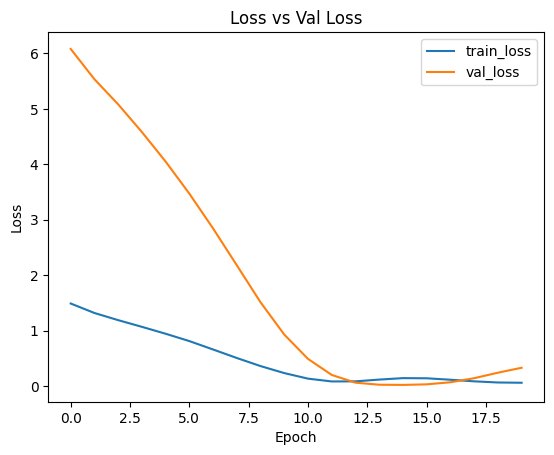

In [ ]:
# 📉 Loss 그래프
# train_loss ↓ 계속 감소
# val_loss ↓ → ↑ → 멈춤

# 🔥 왜 올라가냐? (핵심 이유)
# ❌ 모델이 “암기” 시작함
# 처음:

# 👉 패턴 학습

# 이후:

# 👉 train 데이터 외우기 시작

# 📌 결과
# 데이터	결과
# train	계속 좋아짐
# val	오히려 나빠짐

# 👉 여기서 EarlyStopping 작동

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.title('Loss vs Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
best_epoch = len(history.history['loss']) - early_stop.patience - 1

print("🔥 EarlyStopping 근처 epoch:", best_epoch)

🔥 EarlyStopping 근처 epoch: 14


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 데이터
np.random.seed(42)
X = np.linspace(0, 1, 50)
y = 3 * X + np.random.normal(0, 0.1, 50)
X = X.reshape(-1, 1)

# 모델
model = Sequential([
    Dense(128, activation='relu', input_shape=(1,)),
    Dense(128, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 🔥 1. EarlyStopping 👉 “학습을 멈추는 역할”
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True   # 중요
)

# 🔥 2. ModelCheckpoint 👉 “최고 성능 모델을 저장하는 역할”
checkpoint = ModelCheckpoint(
    "best_model.keras",        # 저장 파일
    monitor='val_loss',        # 기준
    save_best_only=True,       # 최고 성능만 저장
    mode='min',                # loss는 최소값 기준
    verbose=1
)

# 학습
history = model.fit(
    X, y,
    epochs=300,
    validation_split=0.3,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

| 기능  | EarlyStopping | ModelCheckpoint |
| --- | ------------- | --------------- |
| 역할  | 학습 중단         | 모델 저장           |
| 기준  | val_loss      | val_loss        |
| 결과  | 종료            | best 모델 파일      |
| 필요성 | 시간 절약         | 성능 보장           |


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import KFold

# =========================
# 1. 데이터
# =========================
np.random.seed(42)

X = np.linspace(0, 1, 100)
y = 3 * X + np.random.normal(0, 0.1, 100)

X = X.reshape(-1, 1)

# =========================
# 2. K-Fold 설정
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
scores = []

# =========================
# 3. K-Fold 반복
# =========================
for train_idx, val_idx in kf.split(X):

    print(f"\n🔥 Fold {fold}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # =========================
    # 4. 모델 (매 fold마다 새로 생성)
    # =========================
    model = Sequential([
        Dense(64, activation='relu', input_shape=(1,)),
        Dense(64, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    # =========================
    # 5. EarlyStopping
    # =========================
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    # =========================
    # 6. ModelCheckpoint (fold마다 파일 분리)
    # =========================
    checkpoint = ModelCheckpoint(
        f"best_model_fold_{fold}.keras",
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=0
    )

    # =========================
    # 7. 학습
    # =========================
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        callbacks=[early_stop, checkpoint],
        verbose=0
    )

    # =========================
    # 8. 평가
    # =========================
    loss = model.evaluate(X_val, y_val, verbose=0)
    scores.append(loss)

    print(f"Fold {fold} Loss: {loss}")

    fold += 1

# =========================
# 9. 최종 결과
# =========================
print("\n🔥 평균 Loss:", np.mean(scores))


🔥 Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Loss: 0.006145330611616373

🔥 Fold 2
Fold 2 Loss: 0.0045221298933029175

🔥 Fold 3
Fold 3 Loss: 0.19201117753982544

🔥 Fold 4
Fold 4 Loss: 0.04068192094564438

🔥 Fold 5
Fold 5 Loss: 0.014311556704342365

🔥 평균 Loss: 0.051534423138946295
